In [1]:
# import requred libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read excel files
jan = pd.read_excel(r"C:\Users\User\Desktop\Data Analyst\End To End Project\TelcoBillingAvoxi)\Billing_File_022025.xlsx", sheet_name="Jan")
feb = pd.read_excel(r"C:\Users\User\Desktop\Data Analyst\End To End Project\TelcoBillingAvoxi)\Billing_File_022025.xlsx", sheet_name="Feb")     
mar = pd.read_excel(r"C:\Users\User\Desktop\Data Analyst\End To End Project\TelcoBillingAvoxi)\Billing_File_022025.xlsx", sheet_name="March")
client = pd.read_excel(r"C:\Users\User\Desktop\Data Analyst\End To End Project\TelcoBillingAvoxi)\Billing_File_022025.xlsx", sheet_name="Rates - Clients")
vendor = pd.read_excel(r"C:\Users\User\Desktop\Data Analyst\End To End Project\TelcoBillingAvoxi)\Billing_File_022025.xlsx", sheet_name="Rates - Carrier")
'''
print(jan.head())
print(feb.head())
print(mar.head())
print(client.head())
print(vendor.head())
'''

'\nprint(jan.head())\nprint(feb.head())\nprint(mar.head())\nprint(client.head())\nprint(vendor.head())\n'

### Data Cleaning and Integrity Checks

#### Months dataframe


In [2]:
# Renaming columns
def rename_col(df, col_mapping):
    df.rename(columns=col_mapping, inplace=True)
    return df

#print(jan.columns)

col_mapping = {
    "Customer": "customer",
    "Account ID (phone mumber)": "account_id(phone_number)",
    "Duration (Seconds)": "duration_seconds",
    "Called From": "called_from"
}

jan = rename_col(jan, col_mapping)
feb = rename_col(feb, col_mapping) 
mar = rename_col(mar, col_mapping)

#print(jan.head())

In [3]:
# Adding month column
jan["Month"] = "Jan"
feb["Month"] = "Feb"
mar["Month"] = "Mar"

#print(jan.head())


In [4]:
# Concatenate dataframes
by_month = pd.concat([jan, feb, mar], ignore_index=True)

# checking for null
by_month.isna().sum()
by_month.dropna(inplace=True)




### Clients

In [5]:
# rename col
client = client.rename(columns={
     "Account ID (phone mumber)": "account_id(phone_number)",
     "Country": "country",
     "Number Type": "number_type",
     "LandLine Rate": "client_land_rate",
     "Mobile Rate": "client_mobile_rate"
 })
 
client.head()

,account_id(phone_number),country,number_type,client_land_rate,client_mobile_rate
0,200125159,Australia,DID,0.1,0.2
1,201408144,Australia,DID,0.1,0.2
2,201408297,Australia,DID,0.1,0.2
3,201408299,Australia,DID,0.1,0.2
4,201604227,Australia,DID,0.1,0.2


### Vendor



In [6]:
# Rename columns in vendor dataframe
vendor = vendor.rename(columns={
    "Account ID (phone mumber)": "account_id(phone_number)",
     "Vendor": "vendor",
     "Country": "country",
     "Number Type": "number_type",
     "LandLine Rate": "vendor_land_rate",
     "Mobile Rate": "vendor_mobile_rate"
})


print(vendor.head())
#print(vendor.dtypes)
#print(vendor.duplicated().sum())


   account_id(phone_number)    vendor    country number_type  \
0                 200125159  Vendor 1  Australia         DID   
1                 201408144  Vendor 1  Australia         DID   
2                 201408297  Vendor 1  Australia         DID   
3                 201408299  Vendor 1  Australia         DID   
4                 201604227  Vendor 1  Australia         DID   

   vendor_land_rate  vendor_mobile_rate  
0             0.070                0.14  
1             0.075                0.15  
2             0.060                0.12  
3             0.080                0.16  
4             0.050                0.10  


### Analysis and Manipulation


##### Method approach

1. Create a new Master Dataframe for easy manipulation 
2. Merge the master_df, client, and vendor dataframes
3. Analysis Preparation and Visulaization
4. Simulation on Rate Increment
5. DataFrame Simulation for security and comparison
6. Answering Business Questions


In [7]:
# Since the data mentioned that the duration of the call is in seconds, and the rate charge is in minutes. we can convert the duration column into minute and imputed into the dataframe

# Convert "Billed Time (seconds)" to minutes and create a new column "Billed Time (minutes)"
by_month["duration_minutes"] = np.ceil(by_month["duration_seconds"] / 60 )
by_month.columns

Index(['customer', 'account_id(phone_number)', 'duration_seconds',
       'called_from', 'Month', 'duration_minutes'],
      dtype='object')

In [8]:
#print(client.head())
#print(vendor.head())

In [9]:
# Merge all needed columns into one master DataFrame
master_df = by_month.merge(client, on="account_id(phone_number)", how="left")
master_df = master_df.merge(vendor, on=["account_id(phone_number)","country","number_type"], how="left")
master_df.head()

,customer,account_id(phone_number),duration_seconds,called_from,Month,duration_minutes,country,number_type,client_land_rate,client_mobile_rate,vendor,vendor_land_rate,vendor_mobile_rate
0,Client 1,20100405.0,114.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07
1,Client 1,20100405.0,72.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07
2,Client 1,20100405.0,231.0,Landline,Jan,4.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07
3,Client 1,20100405.0,67.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07
4,Client 1,20100405.0,52.0,Landline,Jan,1.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07


In [10]:

# calculating the total charge for each service

def calculate_charge_client(row, landline_rate_increase, mobile_rate_increase, base="master_df"):
    if base == "master_df":
        if row["called_from"] == "Landline":
            return row["duration_minutes"] * row["client_land_rate"]
        elif row["called_from"] == "Mobile":
            return row["duration_minutes"] * row["client_mobile_rate"]
        else:
            return 0
    else:
        if row["called_from"] == "Landline":
            return row["duration_minutes"] * (row["client_land_rate"] * (1 + landline_rate_increase))
        elif row["called_from"] == "Mobile":
            return row["duration_minutes"] * (row["client_mobile_rate"] * (1 + mobile_rate_increase))
        else:
            return 0


# Apply the charge calculation to the merged dataframe
master_df["total_billing_client"] = master_df.apply(lambda row: calculate_charge_client(row,0, 0), axis=1)



In [11]:

# calculate charge based on vendor

def calculate_charge_vendor(row, landline_rate_increase, mobile_rate_increase, base="master_df"):
    seconds = row["duration_seconds"]

    if base == "master_df":
        if row["vendor"] == "Vendor 1" and row["called_from"] == "Landline":
            billed_secs = np.ceil(seconds / 6) * 6
            return (billed_secs / 60) * row["vendor_land_rate"]

        elif row["vendor"] == "Vendor 1" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 6) * 6
            return (billed_secs / 60) * row["vendor_mobile_rate"]

        elif row["vendor"] == "Vendor 2" and row["called_from"] == "Landline":  
            billed_secs = np.ceil(seconds / 1) * 1
            return (billed_secs / 60) * row["vendor_land_rate"]

        elif row["vendor"] == "Vendor 2" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 1) * 1
            return (billed_secs / 60) * row["vendor_mobile_rate"]

        elif row["vendor"] == "Vendor 3" and row["called_from"] == "Landline":
            billed_secs = np.ceil(seconds / 60) * 60
            return (billed_secs / 60) * row["vendor_land_rate"]

        elif row["vendor"] == "Vendor 3" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 60) * 60
            return (billed_secs / 60) * row["vendor_mobile_rate"]

        elif row["vendor"] == "Vendor 4" and row["called_from"] == "Landline":
            if seconds <= 30:
                billed_secs = 30
            else:
                billed_secs = 30 + (np.ceil((seconds - 30) / 6) * 6)
            return (billed_secs / 60) * row["vendor_land_rate"]

        elif row["vendor"] == "Vendor 4" and row["called_from"] == "Mobile":
            if seconds <= 30:
                billed_secs = 30
            else:
                billed_secs = 30 + (np.ceil((seconds - 30) / 6) * 6)
            return (billed_secs / 60) * row["vendor_mobile_rate"]

        elif row["vendor"] == "Vendor 5" and row["called_from"] == "Landline":
            billed_secs = np.ceil(seconds / 30) * 30
            return (billed_secs / 60) * row["vendor_land_rate"]

        elif row["vendor"] == "Vendor 5" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 30) * 30
            return (billed_secs / 60) * row["vendor_mobile_rate"]

        else:
            return 0
    
    else:
        if row["vendor"] == "Vendor 1" and row["called_from"] == "Landline":
            billed_secs = np.ceil(seconds / 6) * 6
            return (billed_secs / 60) * (row["vendor_land_rate"] * 1)

        elif row["vendor"] == "Vendor 1" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 6) * 6
            return (billed_secs / 60) * (row["vendor_mobile_rate"] * 1)

        elif row["vendor"] == "Vendor 2" and row["called_from"] == "Landline":  
            billed_secs = np.ceil(seconds / 1) * 1
            return (billed_secs / 60) * (row["vendor_land_rate"] * 1)

        elif row["vendor"] == "Vendor 2" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 1) * 1
            return (billed_secs / 60) * (row["vendor_mobile_rate"] * 1)

        elif row["vendor"] == "Vendor 3" and row["called_from"] == "Landline":
            billed_secs = np.ceil(seconds / 60) * 60
            return (billed_secs / 60) * (row["vendor_land_rate"] * 1)

        elif row["vendor"] == "Vendor 3" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 60) * 60
            return (billed_secs / 60) * (row["vendor_mobile_rate"] * 1)

        elif row["vendor"] == "Vendor 4" and row["called_from"] == "Landline":
            if seconds <= 30:
                billed_secs = 30
            else:
                billed_secs = 30 + (np.ceil((seconds - 30) / 6) * 6)
            return (billed_secs / 60) * (row["vendor_land_rate"] * 1)

        elif row["vendor"] == "Vendor 4" and row["called_from"] == "Mobile":
            if seconds <= 30:
                billed_secs = 30
            else:
                billed_secs = 30 + (np.ceil((seconds - 30) / 6) * 6)
            return (billed_secs / 60) * (row["vendor_mobile_rate"] * 1)

        elif row["vendor"] == "Vendor 5" and row["called_from"] == "Landline":
            billed_secs = np.ceil(seconds / 30) * 30
            return (billed_secs / 60) * (row["vendor_land_rate"] * 1)

        elif row["vendor"] == "Vendor 5" and row["called_from"] == "Mobile":
            billed_secs = np.ceil(seconds / 30) * 30
            return (billed_secs / 60) * (row["vendor_mobile_rate"] * 1)

        else:
            return 0


# Apply to DataFrame
master_df["total_billing_vendor"] = master_df.apply(lambda row: calculate_charge_vendor(row, 0, 0), axis=1)



In [12]:
master_df["account_id(phone_number)"] = master_df["account_id(phone_number)"].astype(str)
master_df["gross_margin_percent"] = (master_df["total_billing_client"] - master_df["total_billing_vendor"]) / master_df["total_billing_client"] * 100
master_df.head()

,customer,account_id(phone_number),duration_seconds,called_from,Month,duration_minutes,country,number_type,client_land_rate,client_mobile_rate,vendor,vendor_land_rate,vendor_mobile_rate,total_billing_client,total_billing_vendor,gross_margin_percent
0,Client 1,20100405.0,114.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00140,30.0
1,Client 1,20100405.0,72.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00105,47.5
2,Client 1,20100405.0,231.0,Landline,Jan,4.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.004,0.00280,30.0
3,Client 1,20100405.0,67.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00105,47.5
4,Client 1,20100405.0,52.0,Landline,Jan,1.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.001,0.00070,30.0


### Business Questions

81925.52
  customer  total_billing_client
0       4               18095.18
1      37               18065.45
2       8               15150.11
3      26               10389.24
4      10                9210.20
5       3                3809.43
6        1               2288.63
7      15                2177.70
8        2               1477.05
9      22                1262.53


C:\Users\User\AppData\Local\Temp\ipykernel_16904\3105441141.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = total_billing_per_client, x="total_billing_client", y="customer", palette="viridis", legend=False)


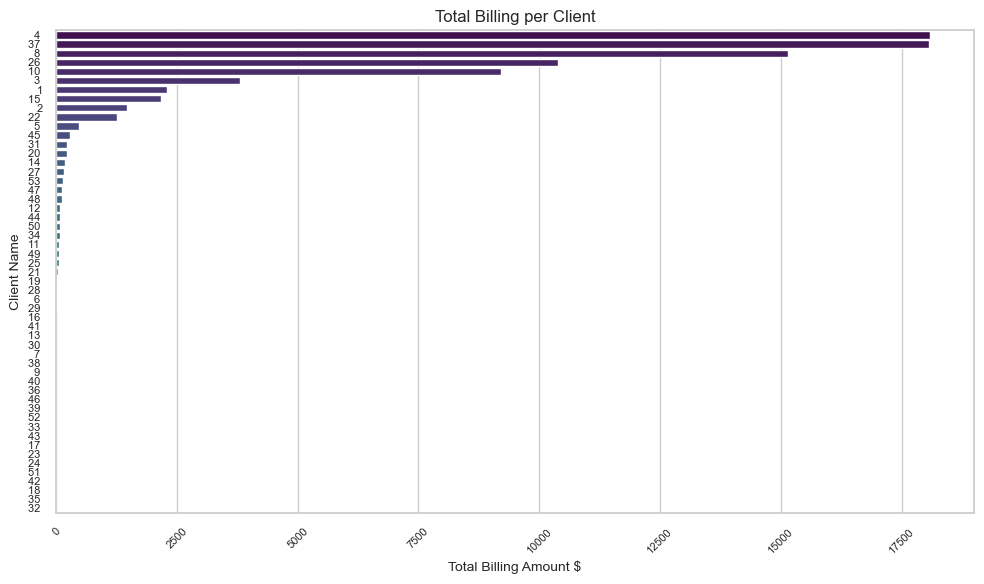

In [13]:
# 1. Total Billing per client

# 1. Total Billing per client
total_billing_per_client = round(master_df.groupby("customer")["total_billing_client"].sum(), 2).reset_index()
total_billing_per_client = total_billing_per_client.sort_values(by="total_billing_client", ascending=False)

# Functions to split name in customer column
def col_names_plit(df, col):
    return df[col].str.split(" ", n=1).str[1]

total_billing_per_client["customer"] = col_names_plit(total_billing_per_client, "customer")
total_10 = total_billing_per_client.head(10)
print(total_10["total_billing_client"].sum())
print(total_billing_per_client.reset_index(drop=True).head(10))

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))     
sns.barplot(data = total_billing_per_client, x="total_billing_client", y="customer", palette="viridis", legend=False)
plt.title("Total Billing per Client",)   
plt.xlabel("Total Billing Amount $", fontsize=10)   
plt.ylabel("Client Name", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
#plt.xscale("log")
plt.tight_layout()
plt.show()

   customer  gross_margin_client
0       39                98.223
1       45                90.590
2       18                86.873
3       32                85.714
4        9                84.148
5        7                73.815
6       24                70.000
7       14                69.999
8       42                64.880
9        6                63.907
10      33                62.685
11      43                62.660
12      35                57.375
13      19                56.290
14      40                55.550
15      16                55.003
16       8                54.607
17      44                54.162
18      13                52.944
19      11                51.211
20      10                47.495
21      41                46.867
22      28                46.685
23      30                45.479
24      46                45.000
25        1               44.789
26      52                43.181
27      17                42.432
28      34                40.530
29      47

C:\Users\User\AppData\Local\Temp\ipykernel_16904\2592879951.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gross_margin_client, x="gross_margin_client", y="customer", palette="Blues_d", legend=False)


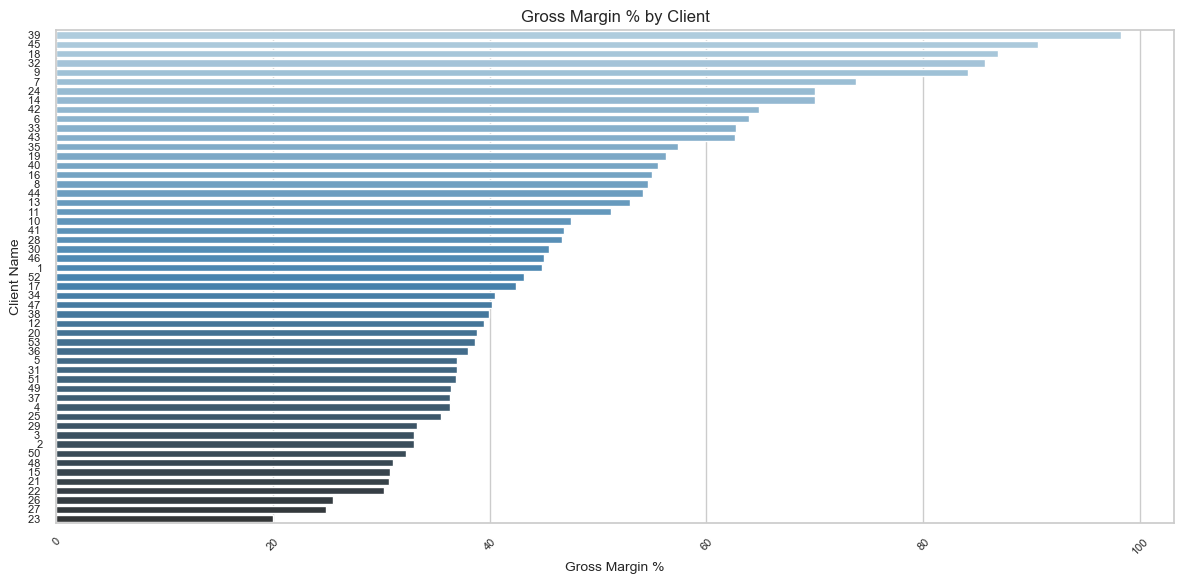

In [14]:
# 2. Gross Margins by Client in (%)
gross_margin_client = (
    ((master_df.groupby("customer")["total_billing_client"].sum() - 
      master_df.groupby("customer")["total_billing_vendor"].sum()) / 
     master_df.groupby("customer")["total_billing_client"].sum()) * 100
).round(3).reset_index(name="gross_margin_percent")
gross_margin_client.columns = ["customer", "gross_margin_client"]
gross_margin_client.sort_values(by="gross_margin_client", ascending=False, inplace=True)

# Applying function to split the customer name
gross_margin_client["customer"] = col_names_plit(gross_margin_client, "customer")
gross_margin_client.reset_index(drop=True, inplace=True)
print(gross_margin_client.reset_index(drop=True))

sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
sns.barplot(data=gross_margin_client, x="gross_margin_client", y="customer", palette="Blues_d", legend=False)
plt.title("Gross Margin % by Client")   
plt.xlabel("Gross Margin %", fontsize=10)
plt.ylabel("Client Name", fontsize=10)
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

          country  gross_margin_percent
0  United Kingdom                 53.54
1          France                 44.69
2    South Africa                 42.82
3           China                 37.90
4          Greece                 36.16
5       Australia                 32.91
6           Chile                 32.15
7   United States                 28.99


C:\Users\User\AppData\Local\Temp\ipykernel_16904\3203426557.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gross_margin_country, x="country", y="gross_margin_percent", palette="BrBG", legend=False)


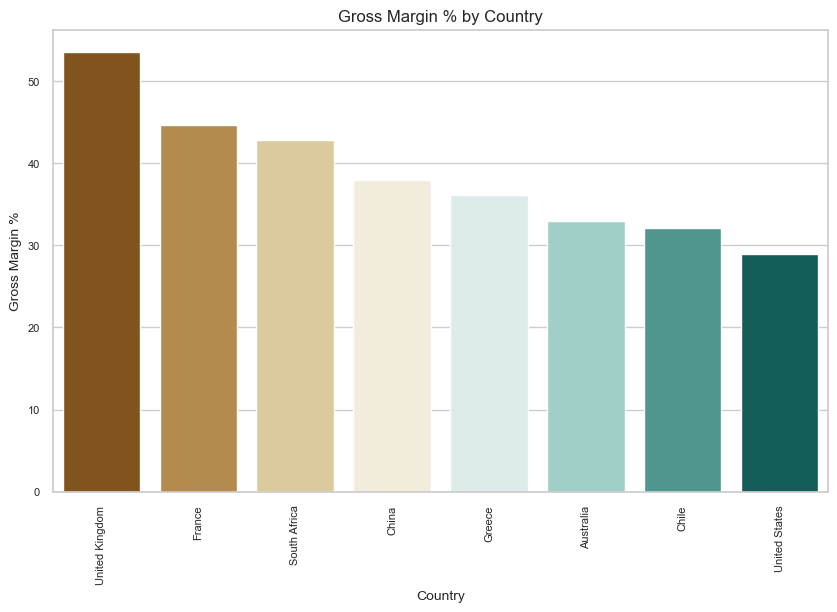

In [15]:
# 3. Gross Margins by Country (%)
gross_margin_country = (
    ((master_df.groupby("country")["total_billing_client"].sum() - 
      master_df.groupby("country")["total_billing_vendor"].sum()) / 
     master_df.groupby("country")["total_billing_client"].sum()) * 100
).round(2).reset_index(name="gross_margin_percent")
gross_margin_country.columns = ["country", "gross_margin_percent"]
gross_margin_country.sort_values(by="gross_margin_percent", ascending=False, inplace=True)
print(gross_margin_country.reset_index(drop=True).head(10))

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))             
sns.barplot(data=gross_margin_country, x="country", y="gross_margin_percent", palette="BrBG", legend=False)
plt.title("Gross Margin % by Country")      
plt.xlabel("Country", fontsize=10)
plt.ylabel("Gross Margin %", fontsize=10)
plt.yticks(fontsize=8)
plt.xticks(rotation=90, fontsize=8)
plt.show()

     vendor  gross_margin_percent
0  Vendor 5                 73.56
1  Vendor 3                 42.53
2  Vendor 2                 40.84
3  Vendor 4                 35.26
4  Vendor 1                 35.09


C:\Users\User\AppData\Local\Temp\ipykernel_16904\1403935814.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gross_margin_vendor, x="vendor", y="gross_margin_percent", palette="BuPu", legend=False)


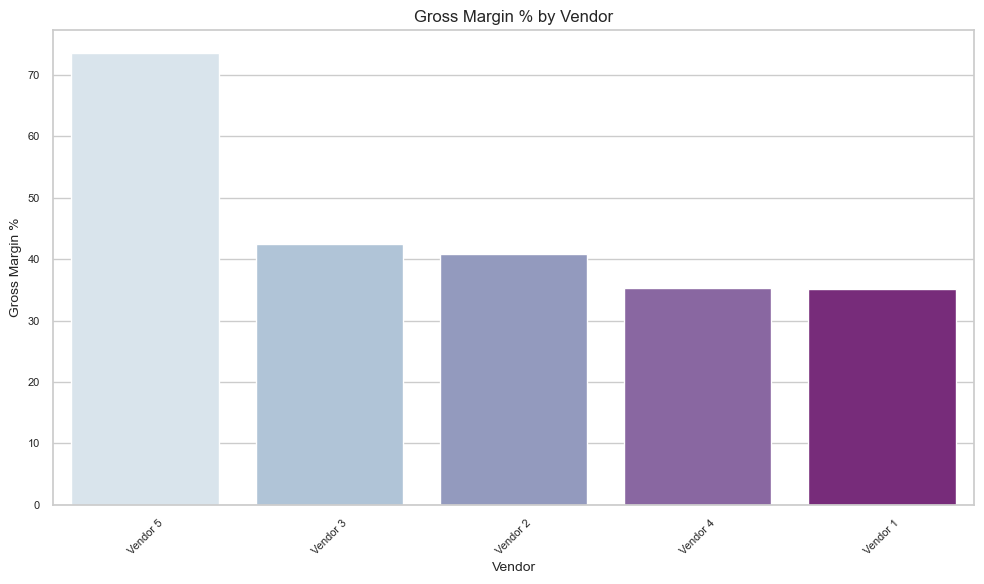

In [16]:
# 4. Gross Margins by Vendor (%)
gross_margin_vendor = (
    ((master_df.groupby("vendor")["total_billing_client"].sum() - 
      master_df.groupby("vendor")["total_billing_vendor"].sum()) / 
     master_df.groupby("vendor")["total_billing_client"].sum()) * 100
).round(2).reset_index(name="gross_margin_percent")
gross_margin_vendor.columns = ["vendor", "gross_margin_percent"]
gross_margin_vendor.sort_values(by="gross_margin_percent", ascending=False, inplace=True)
print(gross_margin_vendor.reset_index(drop=True).head(10))

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=gross_margin_vendor, x="vendor", y="gross_margin_percent", palette="BuPu", legend=False)
plt.title("Gross Margin % by Vendor")
plt.xlabel("Vendor", fontsize=10)
plt.ylabel("Gross Margin %", fontsize=10)
plt.yticks(fontsize=8)
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()



  number_type  gross_margin_percent
0        ITFS                 40.58
1         DID                 38.94
2   TrueLocal                 33.89


C:\Users\User\AppData\Local\Temp\ipykernel_16904\176894506.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gross_margin_number_type, x="number_type", y="gross_margin_percent", palette="Paired", legend=False)


([0, 1, 2], [Text(0, 0, 'ITFS'), Text(1, 0, 'DID'), Text(2, 0, 'TrueLocal')])

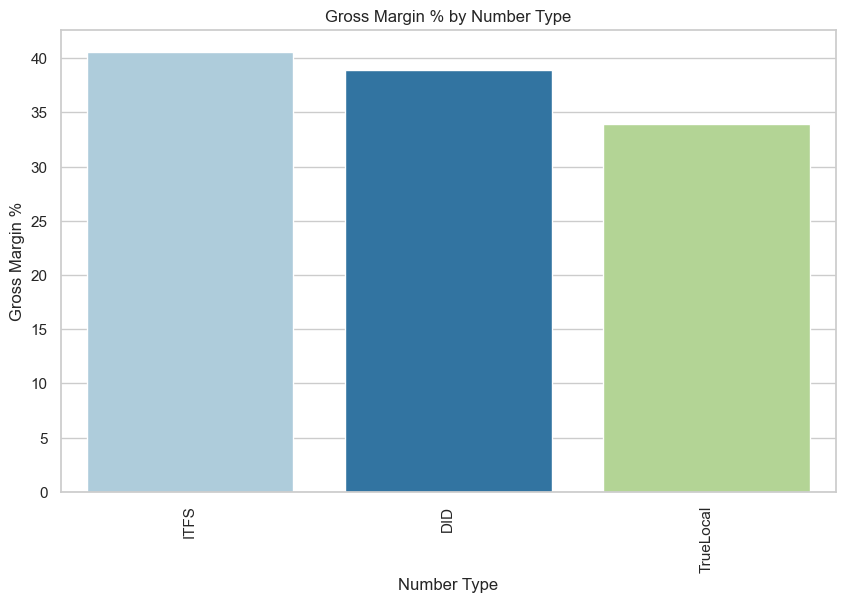

In [17]:
# 5. Gross Margin by Number Type (%)
gross_margin_number_type = (
    ((master_df.groupby("number_type")["total_billing_client"].sum() - 
      master_df.groupby("number_type")["total_billing_vendor"].sum()) / 
     master_df.groupby("number_type")["total_billing_client"].sum()) * 100
).round(2).reset_index(name="gross_margin_percent")

gross_margin_number_type.columns = ["number_type", "gross_margin_percent"]
gross_margin_number_type.sort_values(by="gross_margin_percent", ascending=False, inplace=True)
print(gross_margin_number_type.reset_index(drop=True).head(10))

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=gross_margin_number_type, x="number_type", y="gross_margin_percent", palette="Paired", legend=False)
plt.title("Gross Margin % by Number Type")
plt.xlabel("Number Type")
plt.ylabel("Gross Margin %")
plt.xticks(rotation=90)

     vendor  total_billing_vendor
0  Vendor 4              19275.99
1  Vendor 1              18487.05
2  Vendor 3               7186.48
3  Vendor 2               4483.61
4  Vendor 5               1639.39


C:\Users\User\AppData\Local\Temp\ipykernel_16904\1475329495.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_cost_per_vendor, x="vendor", y="total_billing_vendor", palette="PuOr", legend=False)


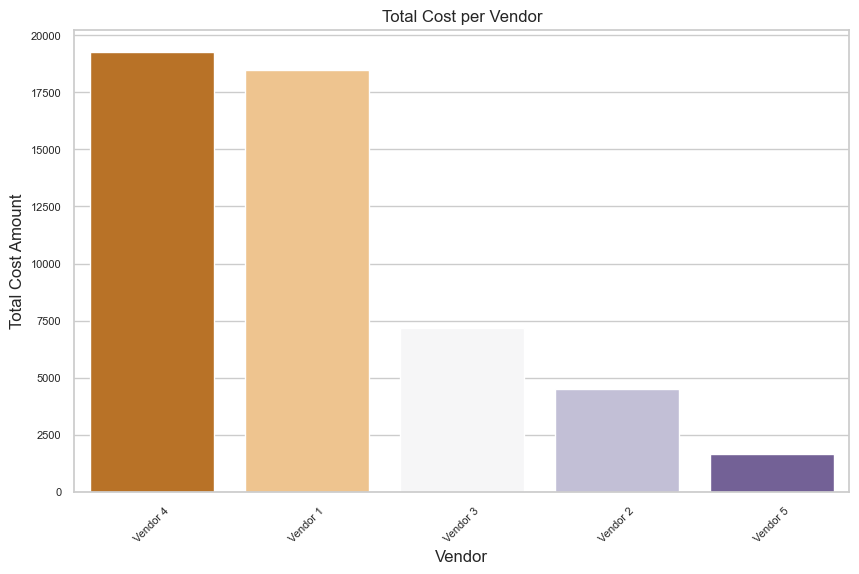

In [18]:
# 6. Total Cost per Vendor
total_cost_per_vendor = round(master_df.groupby("vendor")["total_billing_vendor"].sum(), 2).reset_index()
total_cost_per_vendor.sort_values(by="total_billing_vendor", ascending=False, inplace=True)
print(total_cost_per_vendor.reset_index(drop=True))

sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=total_cost_per_vendor, x="vendor", y="total_billing_vendor", palette="PuOr", legend=False)
plt.title("Total Cost per Vendor")
plt.xlabel("Vendor")
plt.ylabel("Total Cost Amount") 
plt.xticks(rotation=45, fontsize=8)
plt.yticks(fontsize=8)
plt.show()

          country    vendor    customer  total_billing_client  \
0          France  Vendor 2  Client 39                  0.680   
1           China  Vendor 2  Client 26                  0.800   
2  United Kingdom  Vendor 5  Client 20                  0.001   
3  United Kingdom  Vendor 2   Client 5                  0.002   
4          France  Vendor 2  Client 26                 56.480   
5  United Kingdom  Vendor 5  Client 32                  0.003   
6  United Kingdom  Vendor 2  Client 43                  0.003   
7       Australia  Vendor 2  Client 15                 10.400   
8           Chile  Vendor 2  Client 34                 10.373   
9    South Africa  Vendor 2  Client 26                297.110   

   total_billing_vendor  gross_margin                                   label  
0              0.012083     98.223039          France | Vendor 2 | Client 39   
1              0.015333     98.083333           China | Vendor 2 | Client 26   
2              0.000050     95.000000  Unite

C:\Users\User\AppData\Local\Temp\ipykernel_16904\314793457.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gross_margin_country_carrier_client.head(10), x="gross_margin", y="label", palette="PuRd")


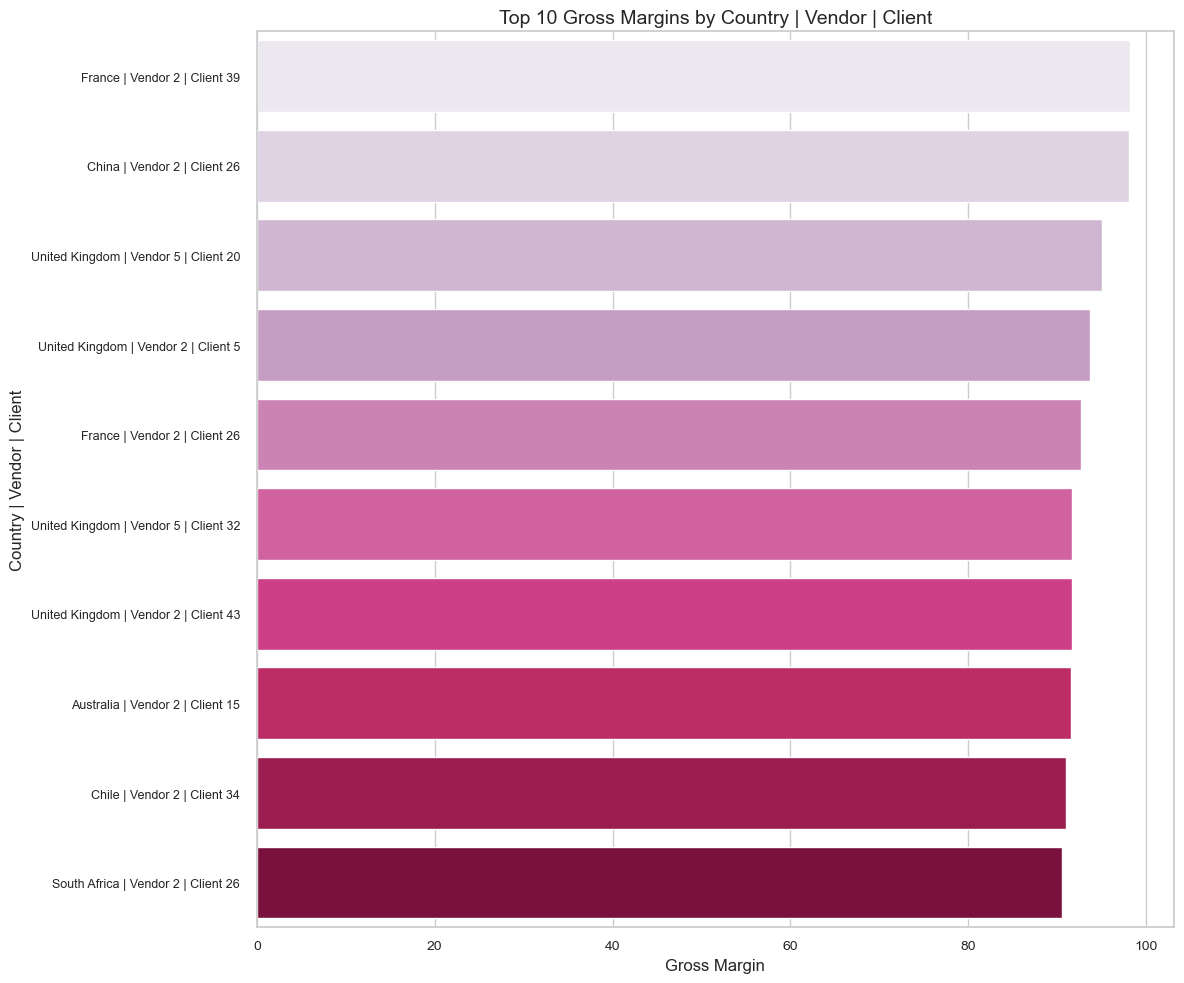

In [19]:
# 7. Gross Margin by Country | Vendor | Client
# Create a new dataframe for combining Country, Vendor, and Client info for gross margin calculation
gross_margin_country_carrier_client = master_df.groupby(["country", "vendor", "customer"]).agg(
    total_billing_client=('total_billing_client', 'sum'),
    total_billing_vendor=('total_billing_vendor', 'sum')
).reset_index()

# Calculate the gross margin for Country | Vendor | Client
gross_margin_country_carrier_client['gross_margin'] = (
    (gross_margin_country_carrier_client['total_billing_client'] - 
     gross_margin_country_carrier_client['total_billing_vendor']) / 
    gross_margin_country_carrier_client['total_billing_client']
) * 100

# Create a label that combines Country, Vendor, and Customer for clarity
gross_margin_country_carrier_client['label'] = (
    gross_margin_country_carrier_client['country'] + " | " +
    gross_margin_country_carrier_client['vendor'] + " | " +
    gross_margin_country_carrier_client['customer']
)

# Sort by gross margin for cleaner visualization
gross_margin_country_carrier_client.sort_values(by="gross_margin", ascending=False, inplace=True)
print(gross_margin_country_carrier_client.reset_index(drop=True).head(10))

# Plot
plt.figure(figsize=(12, 10))
sns.set(style="whitegrid")
sns.barplot(data=gross_margin_country_carrier_client.head(10), x="gross_margin", y="label", palette="PuRd")
plt.title("Top 10 Gross Margins by Country | Vendor | Client", fontsize=14)
plt.xlabel("Gross Margin", fontsize=12)
plt.ylabel("Country | Vendor | Client", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()



In [20]:
master_df.head()

,customer,account_id(phone_number),duration_seconds,called_from,Month,duration_minutes,country,number_type,client_land_rate,client_mobile_rate,vendor,vendor_land_rate,vendor_mobile_rate,total_billing_client,total_billing_vendor,gross_margin_percent
0,Client 1,20100405.0,114.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00140,30.0
1,Client 1,20100405.0,72.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00105,47.5
2,Client 1,20100405.0,231.0,Landline,Jan,4.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.004,0.00280,30.0
3,Client 1,20100405.0,67.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00105,47.5
4,Client 1,20100405.0,52.0,Landline,Jan,1.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.001,0.00070,30.0


###  How would the above change if: increased the mobile rate by 7% and the landline rate by 20%? Ideally,


In [21]:

# Input to automate the rate increase
master_df_updated_rate = master_df.copy()
master_df_updated_rate = master_df_updated_rate.drop(columns=["total_billing_client", "total_billing_vendor", "gross_margin_percent"])

landline_rate_increase = float(input("Enter the landline rate increase percentage: ")) / 100
mobile_rate_increase = float(input("Enter the mobile rate increase percentage: ")) / 100

print(f"Landline Rate Increase: {landline_rate_increase * 100}%")
print(f"Mobile Rate Increase: {mobile_rate_increase * 100}%")

# Recalculate values
master_df_updated_rate["total_billing_client_adjusted"] = master_df_updated_rate.apply(
    lambda row: calculate_charge_client(row, landline_rate_increase, mobile_rate_increase, base="updated"), axis=1
)
master_df_updated_rate["total_billing_vendor_adjusted"] = master_df_updated_rate.apply(
    lambda row: calculate_charge_vendor(row, landline_rate_increase, mobile_rate_increase, base="updated"), axis=1
)




Landline Rate Increase: 100.0%
Mobile Rate Increase: 100.0%


In [22]:

# 1. Recalculate the total billing per client
total_billing_per_client_adjusted = round(master_df_updated_rate.groupby("customer")["total_billing_client_adjusted"].sum(), 2).reset_index()
total_billing_per_client_adjusted = total_billing_per_client_adjusted.sort_values(by="total_billing_client_adjusted", ascending=False)
total_billing_per_client_adjusted["customer"] = col_names_plit(total_billing_per_client_adjusted, "customer")
#print(total_billing_per_client_adjusted.reset_index(drop=True).head(10))

# 2. Recalculate the gross margins by client
gross_margin_client_adjusted = (
    (
        (master_df_updated_rate.groupby("customer")["total_billing_client_adjusted"].sum() - 
         master_df_updated_rate.groupby("customer")["total_billing_vendor_adjusted"].sum()) / 
        master_df_updated_rate.groupby("customer")["total_billing_client_adjusted"].sum()
    ) * 100
).round(3).reset_index(name="gross_margin_percent_adjusted")


gross_margin_client_adjusted.columns = ["customer", "gross_margin_percent_adjusted"]
gross_margin_client_adjusted.sort_values(by="gross_margin_percent_adjusted", ascending=False, inplace=True)
gross_margin_client_adjusted["customer"] = col_names_plit(gross_margin_client_adjusted, "customer")
#print(gross_margin_client_adjusted.reset_index(drop=True).head(10))

# 3. Recalculate the gross margins by country
gross_margin_country_adjusted = (
    (
        (master_df_updated_rate.groupby("country")["total_billing_client_adjusted"].sum() - 
         master_df_updated_rate.groupby("country")["total_billing_vendor_adjusted"].sum()) / 
        master_df_updated_rate.groupby("country")["total_billing_client_adjusted"].sum()
    ) * 100
).round(3).reset_index(name="gross_margin_percent_adjusted")

gross_margin_country_adjusted.columns = ["country", "gross_margin_percent_adjusted"]
gross_margin_country_adjusted.sort_values(by="gross_margin_percent_adjusted", ascending=False, inplace=True)
#print(gross_margin_country_adjusted.reset_index(drop=True).head(10))

# 4. Recalculate the gross margins by vendor
gross_margin_vendor_adjusted = (
    (
        (master_df_updated_rate.groupby("vendor")["total_billing_client_adjusted"].sum() - 
         master_df_updated_rate.groupby("vendor")["total_billing_vendor_adjusted"].sum()) / 
        master_df_updated_rate.groupby("vendor")["total_billing_client_adjusted"].sum()
    ) * 100
).round(3).reset_index(name="gross_margin_percent_adjusted")

gross_margin_vendor_adjusted.columns = ["vendor", "gross_margin_percent_adjusted"]
gross_margin_vendor_adjusted.sort_values(by="gross_margin_percent_adjusted", ascending=False, inplace=True)
#print(gross_margin_vendor_adjusted.reset_index(drop=True).head(10))

# 5. Recalculate the gross margins by number type
gross_margin_number_type_adjusted = (
    (
        (master_df_updated_rate.groupby("number_type")["total_billing_client_adjusted"].sum() - 
         master_df_updated_rate.groupby("number_type")["total_billing_vendor_adjusted"].sum()) / 
        master_df_updated_rate.groupby("number_type")["total_billing_client_adjusted"].sum()
    ) * 100
).round(3).reset_index(name="gross_margin_percent_adjusted")

gross_margin_number_type_adjusted.columns = ["number_type", "gross_margin_percent_adjusted"]
gross_margin_number_type_adjusted.sort_values(by="gross_margin_percent_adjusted", ascending=False, inplace=True)
#print(gross_margin_number_type_adjusted.reset_index(drop=True).head(10))   

# 6. Recalculate the total cost per vendor
total_cost_per_vendor_adjusted = round(master_df_updated_rate.groupby("vendor")["total_billing_vendor_adjusted"].sum(), 2).reset_index()
total_cost_per_vendor_adjusted.sort_values(by="total_billing_vendor_adjusted", ascending=False, inplace=True)
#print(total_cost_per_vendor_adjusted.reset_index(drop=True).head(10))

In [23]:
# FUnction to compare two dataframes
def comparison_with_adjusted(df1, df2, key_col, col1, col2):
    comparison_df = pd.merge(df1, df2, on=key_col, how="outer")
    
    comparison_df = comparison_df.rename(columns={
        comparison_df.columns[1]: col1,
        comparison_df.columns[2]: col2
    })
    comparison_df["difference"] = comparison_df[col2] - comparison_df[col1]
    return comparison_df


total_billing_comparison = comparison_with_adjusted(
    total_billing_per_client, total_billing_per_client_adjusted, key_col="customer", col1="total_billing_client", col2="total_billing_client_adjusted"
)

display(total_billing_comparison.head(10))




,customer,total_billing_client,total_billing_client_adjusted,difference
0,4,18095.18,36190.35,18095.17
1,37,18065.45,36130.90,18065.45
2,8,15150.11,30300.23,15150.12
3,26,10389.24,20778.48,10389.24
4,10,9210.20,18420.40,9210.20
5,3,3809.43,7618.85,3809.42
6,1,2288.63,4577.25,2288.62
7,15,2177.70,4355.40,2177.70
8,2,1477.05,2954.11,1477.06
9,22,1262.53,2525.05,1262.52


In [24]:
# Gross Margins by Client Comparison in (%)
gross_margin_client_comparison = comparison_with_adjusted(
    gross_margin_client, gross_margin_client_adjusted, key_col="customer", col1="gross_margin_client", col2="gross_margin_percent_adjusted" 
)

display(gross_margin_client_comparison.head(10))

,customer,gross_margin_client,gross_margin_percent_adjusted,difference
0,39,98.223,99.112,0.889
1,45,90.590,95.295,4.705
2,18,86.873,93.436,6.563
3,32,85.714,92.857,7.143
4,9,84.148,92.074,7.926
5,7,73.815,86.907,13.092
6,24,70.000,85.000,15.000
7,14,69.999,85.000,15.001
8,42,64.880,82.440,17.560
9,6,63.907,81.954,18.047


In [25]:
# Gross Margins by Country Comparison in a % form

gross_margin_country_comparison = comparison_with_adjusted(
    gross_margin_country, gross_margin_country_adjusted, key_col="country", col1="gross_margin_percent", col2="gross_margin_percent_adjusted"
)
display(gross_margin_country_comparison.head(10))



,country,gross_margin_percent,gross_margin_percent_adjusted,difference
0,United Kingdom,53.54,76.771,23.231
1,France,44.69,72.343,27.653
2,South Africa,42.82,71.412,28.592
3,China,37.90,68.948,31.048
4,Greece,36.16,68.079,31.919
5,Australia,32.91,66.457,33.547
6,Chile,32.15,66.074,33.924
7,United States,28.99,64.497,35.507


In [26]:
# Gross Margins by Carrier Comparison in a % form
gross_margin_vendor_comparison = comparison_with_adjusted(
    gross_margin_vendor, gross_margin_vendor_adjusted, key_col="vendor", col1="gross_margin_percent", col2="gross_margin_percent_adjusted"
)
display(gross_margin_vendor_comparison.head(10))

,vendor,gross_margin_percent,gross_margin_percent_adjusted,difference
0,Vendor 5,73.56,86.780,13.220
1,Vendor 3,42.53,71.263,28.733
2,Vendor 2,40.84,70.422,29.582
3,Vendor 4,35.26,67.630,32.370
4,Vendor 1,35.09,67.547,32.457


In [27]:
# Gross Margins by Number Comparison in a % form
gross_margin_number_type_comparison = comparison_with_adjusted(
    gross_margin_number_type, gross_margin_number_type_adjusted, key_col="number_type", col1="gross_margin_percent", col2="gross_margin_percent_adjusted"
)
display(gross_margin_number_type_comparison.head(10))

,number_type,gross_margin_percent,gross_margin_percent_adjusted,difference
0,ITFS,40.58,70.288,29.708
1,DID,38.94,69.469,30.529
2,TrueLocal,33.89,66.946,33.056


In [28]:
# Total Cost per Vendor Comparison in a $ form
total_cost_per_vendor_comparison = comparison_with_adjusted(
    total_cost_per_vendor, total_cost_per_vendor_adjusted, key_col="vendor", col1="total_billing_vendor", col2="total_billing_vendor_adjusted"
)
display(total_cost_per_vendor_comparison.head(10))

,vendor,total_billing_vendor,total_billing_vendor_adjusted,difference
0,Vendor 4,19275.99,19275.99,0.0
1,Vendor 1,18487.05,18487.05,0.0
2,Vendor 3,7186.48,7186.48,0.0
3,Vendor 2,4483.61,4483.61,0.0
4,Vendor 5,1639.39,1639.39,0.0


In [29]:
# Calculate gross margin percentage based on updated rates
master_df_updated_rate["gross_margin_percent_updated"] = ((master_df_updated_rate["total_billing_client_adjusted"] - master_df_updated_rate["total_billing_vendor_adjusted"]) / master_df_updated_rate["total_billing_client_adjusted"] ) * 100
master_df_updated_rate.head()

,customer,account_id(phone_number),duration_seconds,called_from,Month,duration_minutes,country,number_type,client_land_rate,client_mobile_rate,vendor,vendor_land_rate,vendor_mobile_rate,total_billing_client_adjusted,total_billing_vendor_adjusted,gross_margin_percent_updated
0,Client 1,20100405.0,114.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.004,0.00140,65.00
1,Client 1,20100405.0,72.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.004,0.00105,73.75
2,Client 1,20100405.0,231.0,Landline,Jan,4.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.008,0.00280,65.00
3,Client 1,20100405.0,67.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.004,0.00105,73.75
4,Client 1,20100405.0,52.0,Landline,Jan,1.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00070,65.00


### Changes I would make to have the overall Gross Margin to be at 45%


In [30]:
target_vendor_billing = master_df["total_billing_client"].sum() * 0.55
actual_vendor_billing = master_df["total_billing_vendor"].sum()
difference_needed = actual_vendor_billing - target_vendor_billing
difference_needed

print(f"To reach a 45% overall gross margin, the company need to reduce the total vendor cost by approximately ${difference_needed:.2f}.")

To reach a 45% overall gross margin, the company need to reduce the total vendor cost by approximately $4575.30.


In [31]:
#### simulation on the vendor cost to reach the target gross margin
master_df["target_vendor_billing_45_margin"] = master_df["total_billing_client"] * 0.55
master_df["vendor_cost_reduction_needed"] = master_df["total_billing_vendor"] - master_df["target_vendor_billing_45_margin"]
master_df.head()

,customer,account_id(phone_number),duration_seconds,called_from,Month,duration_minutes,country,number_type,client_land_rate,client_mobile_rate,vendor,vendor_land_rate,vendor_mobile_rate,total_billing_client,total_billing_vendor,gross_margin_percent,target_vendor_billing_45_margin,vendor_cost_reduction_needed
0,Client 1,20100405.0,114.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00140,30.0,0.00110,0.00030
1,Client 1,20100405.0,72.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00105,47.5,0.00110,-0.00005
2,Client 1,20100405.0,231.0,Landline,Jan,4.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.004,0.00280,30.0,0.00220,0.00060
3,Client 1,20100405.0,67.0,Landline,Jan,2.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.002,0.00105,47.5,0.00110,-0.00005
4,Client 1,20100405.0,52.0,Landline,Jan,1.0,Greece,DID,0.001,0.1,Vendor 5,0.0007,0.07,0.001,0.00070,30.0,0.00055,0.00015


In [32]:
estimation_vendor_cost_reduction = master_df.groupby("vendor")["vendor_cost_reduction_needed"].sum().sort_values(ascending=False).reset_index().round(2)
print("The estimation of cost reduction per vendor listed as below:\n", estimation_vendor_cost_reduction)

The estimation of cost reduction per vendor listed as below:
      vendor  vendor_cost_reduction_needed
0  Vendor 4                       2900.05
1  Vendor 1                       2821.73
2  Vendor 2                        314.97
3  Vendor 3                        309.29
4  Vendor 5                      -1770.75




#### Vendor 4 and Vendor 1:
- These two vendors account for **~70%** of the total cost reduction required.
- Focus negotiation or routing optimization efforts here first.

#### Vendor 5:
- Already performing above the required margin with a surplus of approximately **2,004**.
- Could potentially handle a higher traffic load** to offset higher-cost vendors.

#### Vendor 2 and Vendor 3:
- Require moderate cost reductions.
- Consider **adjusting routing rules** slightly if cost flexibility with Vendor 4/1 is limited.

---

#### Recommendation:

- Prioritize renegotiations with Vendor 4 and Vendor 1 to bring their pricing closer to the target vendor cost level.
- Analyze routing patterns: Shift more volume to Vendor 5 where feasible (if quality/SLA allows).
- Set cost benchmarks internally based on Vendor 5’s performance.
- If renegotiation isn’t feasible, explore alternative vendors** or lower-cost routes for high-volume destinations.
